#Iris Flower Classification

## CodeAlpha Data Science Internship — Task 1

### Project Overview

This project focuses on classifying Iris flowers into three species:
- Setosa
- Versicolor
- Virginica

The classification is performed using flower measurements as input features and a machine learning classification model built using Scikit-learn.

### Objectives

- Use Iris flower measurements as input data.
- Classify flowers into Setosa, Versicolor, and Virginica species.
- Build a machine learning classification model using Scikit-learn.
- Evaluate the model using test data.
- Measure classification accuracy and overall performance.
- Understand the fundamental workflow of a classification problem.

In [10]:
# Import required libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

print("Libraries imported successfully!")

Libraries imported successfully!


In [12]:
# Load the CodeAlpha Iris dataset

df = pd.read_csv("/content/Iris.csv")

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [13]:
# Display first 5 rows

df.head()


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [14]:
# Display last 5 rows

df.tail()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
145,146,6.7,3.0,5.2,2.3,Iris-virginica
146,147,6.3,2.5,5.0,1.9,Iris-virginica
147,148,6.5,3.0,5.2,2.0,Iris-virginica
148,149,6.2,3.4,5.4,2.3,Iris-virginica
149,150,5.9,3.0,5.1,1.8,Iris-virginica


In [15]:
# Check number of rows and columns

print("Number of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])

Number of Rows: 150
Number of Columns: 6


In [16]:
# Display all column names

print("Columns in the dataset:")
print(df.columns.tolist())

Columns in the dataset:
['Id', 'SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm', 'Species']


In [17]:
# Display dataset information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


In [18]:
# Check for missing values

missing_values = df.isnull().sum()

print("Missing values in each column:")
print(missing_values)

Missing values in each column:
Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64


In [19]:
# Check for duplicate rows

duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


In [20]:
# Generate statistical summary of numerical columns

df.describe()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,75.500000,5.843333,3.054000,3.758667,1.198667
std,43.445368,0.828066,0.433594,1.764420,0.763161
min,1.000000,4.300000,2.000000,1.000000,0.100000
25%,38.250000,5.100000,2.800000,1.600000,0.300000
50%,75.500000,5.800000,3.000000,4.350000,1.300000
75%,112.750000,6.400000,3.300000,5.100000,1.800000
max,150.000000,7.900000,4.400000,6.900000,2.500000


In [21]:
# Count the number of samples for each Iris species

species_counts = df["Species"].value_counts()

print(species_counts)

Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64


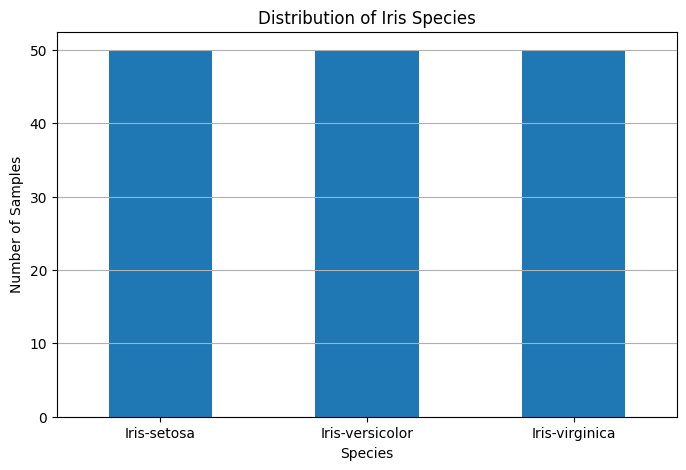

In [22]:
# Visualize the distribution of Iris species

plt.figure(figsize=(8, 5))

species_counts.plot(kind="bar")

plt.title("Distribution of Iris Species")
plt.xlabel("Species")
plt.ylabel("Number of Samples")
plt.xticks(rotation=0)
plt.grid(axis="y")

plt.show()

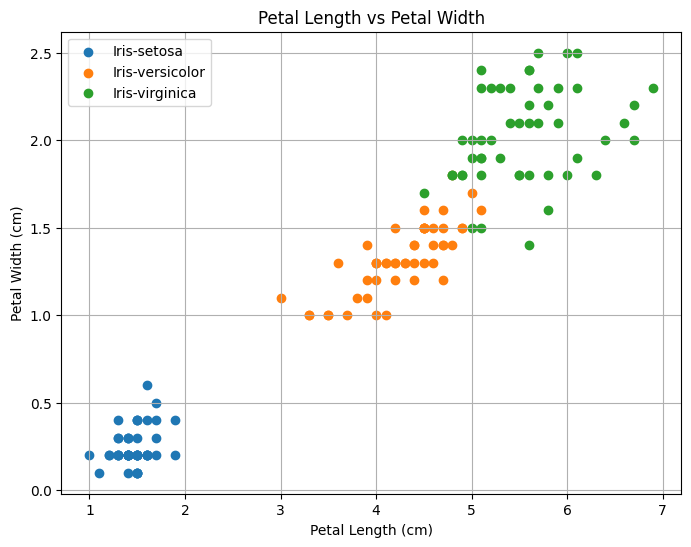

In [23]:
# Scatter plot: Petal Length vs Petal Width

plt.figure(figsize=(8, 6))

for species in df["Species"].unique():
    subset = df[df["Species"] == species]

    plt.scatter(
        subset["PetalLengthCm"],
        subset["PetalWidthCm"],
        label=species
    )

plt.xlabel("Petal Length (cm)")
plt.ylabel("Petal Width (cm)")
plt.title("Petal Length vs Petal Width")
plt.legend()
plt.grid(True)

plt.show()

In [24]:
# Select input features

features = [
    "SepalLengthCm",
    "SepalWidthCm",
    "PetalLengthCm",
    "PetalWidthCm"
]

X = df[features]

# Select target variable
y = df["Species"]

print("Features:")
print(X.head())

print("\nTarget:")
print(y.head())

Features:
   SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm
0            5.1           3.5            1.4           0.2
1            4.9           3.0            1.4           0.2
2            4.7           3.2            1.3           0.2
3            4.6           3.1            1.5           0.2
4            5.0           3.6            1.4           0.2

Target:
0    Iris-setosa
1    Iris-setosa
2    Iris-setosa
3    Iris-setosa
4    Iris-setosa
Name: Species, dtype: object


In [25]:
from sklearn.preprocessing import LabelEncoder

# Encode target species into numerical labels

label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y)

print("Species classes:")
for number, species in enumerate(label_encoder.classes_):
    print(f"{number} → {species}")

Species classes:
0 → Iris-setosa
1 → Iris-versicolor
2 → Iris-virginica


In [26]:
# Split the dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.20,
    random_state=42,
    stratify=y_encoded
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 120
Testing samples: 30


In [27]:
# Standardize the input features (feature scaling)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed successfully.")

Feature scaling completed successfully.


In [28]:
# Create and train the Logistic Regression model

model = LogisticRegression(
    max_iter=200,
    random_state=42
)

model.fit(X_train_scaled, y_train)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


In [29]:
# Make predictions on the unseen test data

y_pred = model.predict(X_test_scaled)

print("Predictions generated successfully!")
print("Predicted labels:")
print(y_pred)

Predictions generated successfully!
Predicted labels:
[0 2 1 1 0 1 0 0 2 1 2 2 2 1 0 0 0 1 1 2 0 2 1 1 2 2 1 0 2 0]


In [30]:
# Calculate model accuracy

accuracy = accuracy_score(y_test, y_pred)

print(f"Model Accuracy: {accuracy * 100:.2f}%")

Model Accuracy: 93.33%


In [31]:
# Generate classification report

report = classification_report(
    y_test,
    y_pred,
    target_names=label_encoder.classes_
)

print("Classification Report:")
print(report)

Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       0.90      0.90      0.90        10
 Iris-virginica       0.90      0.90      0.90        10

       accuracy                           0.93        30
      macro avg       0.93      0.93      0.93        30
   weighted avg       0.93      0.93      0.93        30



In [32]:
# Generate confusion matrix

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[10  0  0]
 [ 0  9  1]
 [ 0  1  9]]


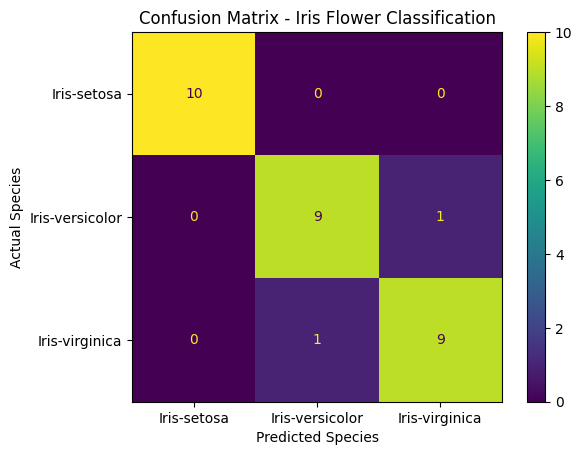

In [33]:
# Visualize the confusion matrix

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_encoder.classes_
)

disp.plot()

plt.title("Confusion Matrix - Iris Flower Classification")
plt.xlabel("Predicted Species")
plt.ylabel("Actual Species")

plt.show()

In [50]:
# Compare actual and predicted labels

comparison = pd.DataFrame({
    "Actual": label_encoder.inverse_transform(y_test),
    "Predicted": label_encoder.inverse_transform(y_pred)
})

comparison.head(10)

,Actual,Predicted
0,Iris-setosa,Iris-setosa
1,Iris-virginica,Iris-virginica
2,Iris-versicolor,Iris-versicolor
3,Iris-versicolor,Iris-versicolor
4,Iris-setosa,Iris-setosa
5,Iris-versicolor,Iris-versicolor
6,Iris-setosa,Iris-setosa
7,Iris-setosa,Iris-setosa
8,Iris-virginica,Iris-virginica
9,Iris-versicolor,Iris-versicolor


In [48]:
# Test the model with a new flower measurement

sample_flower = np.array([
    [5.1, 3.5, 1.4, 0.2]
])

sample_scaled = scaler.transform(sample_flower)

sample_prediction = model.predict(sample_scaled)

predicted_species = label_encoder.inverse_transform(sample_prediction)

print("Sample Flower Measurements:")
print("Sepal Length: 5.1 cm")
print("Sepal Width : 3.5 cm")
print("Petal Length: 1.4 cm")
print("Petal Width : 0.2 cm")

print("\nPredicted Species:", predicted_species[0])

Sample Flower Measurements:
Sepal Length: 5.1 cm
Sepal Width : 3.5 cm
Petal Length: 1.4 cm
Petal Width : 0.2 cm

Predicted Species: Iris-setosa


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [51]:
# Final model evaluation summary

print("=" * 55)
print("IRIS FLOWER CLASSIFICATION - MODEL RESULTS")
print("=" * 55)

print(f"Total Dataset Samples : {len(df)}")
print(f"Training Samples      : {len(X_train)}")
print(f"Testing Samples       : {len(X_test)}")
print(f"Number of Features    : {X.shape[1]}")
print(f"Number of Classes     : {len(label_encoder.classes_)}")
print(f"Model                 : Logistic Regression")
print(f"Accuracy              : {accuracy * 100:.2f}%")

print("\nClasses:")
for species in label_encoder.classes_:
    print(f"- {species}")

print("=" * 55)

IRIS FLOWER CLASSIFICATION - MODEL RESULTS
Total Dataset Samples : 150
Training Samples      : 120
Testing Samples       : 30
Number of Features    : 4
Number of Classes     : 3
Model                 : Logistic Regression
Accuracy              : 93.33%

Classes:
- Iris-setosa
- Iris-versicolor
- Iris-virginica


## Key Findings

- The Iris dataset contains 150 flower samples belonging to three species:
  Iris-setosa, Iris-versicolor, and Iris-virginica.
- Each species contains 50 samples, making the dataset balanced across all three classes.
- Four flower measurements were used as input features: sepal length, sepal width,
  petal length, and petal width.
- Exploratory visualization showed that Iris-setosa is clearly separated from the
  other species based on petal measurements.
- Some overlap was observed between Iris-versicolor and Iris-virginica.
- The Logistic Regression model achieved an accuracy of 93.33% on the unseen test data.
- Iris-setosa achieved perfect precision, recall, and F1-score of 1.00.
- One Iris-versicolor sample was classified as Iris-virginica, and one
  Iris-virginica sample was classified as Iris-versicolor.
- Overall, the model demonstrated strong performance in classifying Iris flower species.

## Conclusion

In this project, a machine learning classification model was developed to classify
Iris flowers into Iris-setosa, Iris-versicolor, and Iris-virginica using four
flower measurements.

The dataset was explored and verified for its structure, missing values, duplicate
records, and class distribution before model development. Exploratory visualization
was also performed to understand the relationship between flower measurements and
species.

A Logistic Regression classification model was trained using the selected flower
measurements. The dataset was divided into training and testing sets, and feature
scaling was applied before model training.

The model achieved an accuracy of 93.33% on the test dataset. The classification
report and confusion matrix showed that Iris-setosa was classified perfectly, while
the only misclassifications occurred between Iris-versicolor and Iris-virginica.

Overall, the project demonstrates the application of supervised machine learning
for multi-class classification and shows that flower measurements can be effectively
used to distinguish different Iris species.

## Technologies and Libraries Used

- Python
- Pandas — Data loading and manipulation
- NumPy — Numerical operations
- Matplotlib — Data visualization
- Scikit-learn — Machine learning, preprocessing, model training, and evaluation
- Google Colab — Development environment

## Project Workflow

1. Load the Iris dataset
2. Inspect the dataset structure
3. Check for missing and duplicate values
4. Analyze species distribution
5. Perform exploratory data visualization
6. Select input features and target variable
7. Encode target labels
8. Split data into training and testing sets
9. Standardize the input features
10. Train the Logistic Regression model
11. Generate predictions on test data
12. Evaluate model accuracy
13. Generate classification report
14. Analyze confusion matrix
15. Perform sample prediction
16. Summarize findings and conclusion

Task 1 Requirement Coverage

| Requirement | Implementation |
|---|---|
| Use Iris flower measurements | Four sepal and petal measurements used |
| Classify Iris species | Setosa, Versicolor, and Virginica classified |
| Use Scikit-learn | Scikit-learn used for preprocessing, model training, and evaluation |
| Evaluate accuracy and performance | Accuracy, precision, recall, F1-score, and confusion matrix used |
| Understand classification concepts | Multi-class supervised classification workflow implemented |